## Running CL Simulations

We now have 
- Elo data
- A model that predicts number of goals based on Elo diff and whether or not there is a home advantage.

From this, we are able to simulate a Champions League tournament. To do so, we must research the current tournament format, and which teams are included. Note that we are focused on simulating Manchester United's run through the tournament primarily.

### League format

#### 1. Qualifying (we can ignore this as Manchester United have already qualified for the 26-27 tournament)

#### 2. League stage

There is one table containing all 36 teams. 

Each team plays 8 matches (4 home, 4 away) vs 8 different teams.

Teams are divided into 4 pots of 9, based on a UEFA club coefficient assignment system. Each club plays two teams from each pot, one home and one away. This is to prevent a club from facing a team from their own domestic league, and to stop a club from facing more than 2 clubs from any other domestic league. 

Manchester United's group phase would look like: 
- Pot 1: one home, one away 
- Pot 2: one home, one away 
- Pot 3: one home, one away 
- Pot 4: one home, one away 

The results are fed into one table as so:
- Win:     3 points 
- Draw:    1 point 
- Loss:   0 points

After 8 games:
- 1st–8th: directly to Round of 16
- 9th–24th: knockout play-off
- 25th–36th: eliminated

For teams tied in league rankings, the tiebreakers are goal (in order) goal difference, goals scored, away gaols scored, wins, away wins, various disciplinary criteria. We can choose a way to approximate deep ties (likely randomisation)

#### 3. Knockout play off

The teams finishing 9th - 24th play a 2 legged tie. The draw is:
- 9th / 10th vs 23rd / 24th  
- 11th / 12th vs 21st / 22nd  
- 13th / 14th vs 19th / 20th  
- 15th / 16th vs 17th / 18th

The higher ranked side plays at home in the second leg (irrelevant for our tournament).
The 8 winners join the top eight teams in the round of 16.

#### Round of 16 and onward

The top eight are seeded into the Ro16 based on their league position. 
All Ro16, quarter finals and semi finals matches are 2 legged aggegrate ties. 
The final is a single match.

Note (from UEFA):
'The new 2026/27 rules also preserve some league-phase seeding advantages further into the bracket: teams ranked 1–4 are due to play the second leg at home in the quarter-finals, and teams ranked 1–2 in the semi-finals. If they are knocked out, the team that beats them inherits that bracket position.'

## How our model will simulate this

#### 1. Qualifying

First gather the teams. 29 teams (including Man Utd) have already qualified:

Arsenal, Aston Villa, Athletico Madrid, Borussia Dortmund, Barcelona, Bayern Munich, Club Brugge, Como, Feyenoord, Galatasaray, Inter, leipzig, Lens, Lille, Liverpool, Man City, Man Utd, Napoli, Paris, Porto, PSV, Real Betis, Real Madrid, Roma, Shakhtar, Slavia Praha, Sporting CP, Stuttgart, Villareal

The remaining 7 places will be decided by playoffs in the coming weeks (18-26 Aug). Until then, we will randomise these playoffs to generate the list of teams. The playoffs are as follows:

Champions Path

- Levski Sofia        vs AEK Athens
- Celtic              vs LASK
- Dinamo Zagreb       vs Viking
- Slovan Bratislava   vs Celje
- Hapoel Be'er Sheva  vs Sabah

League Path

- Fenerbahçe          vs Lyon
- NEC                 vs Bodø/Glimt

Where no data exists in our model on the team, we can find data from elsewhere, or choose uniformly.

#### 2. League stage

We need to find out the exact rules behind the pots. 4 pots of 9, non random but assigned by UEFA's club coefficient rankings at the start of the season. The CL holders are placed as the top seed in Pot 1. So we will need to import UEFA coefficients into our data team (can be attached to the teams csv maybe)

After investigation of the possible qualifiers, (due to their low ranking) it would appear that Pots 1 and 2 are virtually fixed: \
Pot 1 \
PSG \
Bayern Munich \
Real Madrid \
Liverpool \
Inter \
Manchester City \
Arsenal \
Barcelona \
Atletico Madrid 

Pot 2 \
Borussia Dortmund \
Roma \
Sporting CP \
Aston Villa \
Porto\ 
Manchester United\ 
Club Brugge \
Real Betis \
PSV 

Pot 3 (contains 7 guaranteed teams:) \
Feyenoord \
Lille \
Napoli \
RB Leipzig \
Villarreal \
Shakhtar Donetsk \
Galatasaray, and 2 more places dependent on qualifying

Pot 4 (contains 4 guaranteed teams):
Slavia Prague \
Stuttgart \
Como \
Lens, with the remaining 5 places dependent on qualifying

It is possible to asssign each team to the correct pot from its coefficient. 

Once the pots are picked, we need a way to choose 2 teams from each pot for each team, such that none of the restrictions are breached. We coudl define a function that chooses a random pot choice, checks the tree choices for the tournament (check complexity), and rejects. Need to investigate how common a failure is. Can just run Monte carlo, and if failure comes ignore this trial.

Once teams from pots are chosen, simulating the league is realtively trivial.

#### 3. Knockout play-off

Then need to choose uniformly from the possible pairings and run the playoffs

#### 4. Round of 16 and onward

Seed top 8 into the top seeds
Seed next teams according to new 26/27 rules
Run sim





### Data and simulation prep

For convenience, we'll build a small dataframe containing 

team, team_id, country, elo, uefa coefficient, qualified. This will be easier to work with than our full database

In [5]:
import pandas as pd
import sqlite3
import soccerdata as sd
import numpy as np

In [6]:
connection = sqlite3.connect("../data/processed/football.db")

matches = pd.read_sql_query(
    "SELECT * FROM matches",
    connection
)

matches = matches.sort_values("date").reset_index(drop=True)

In [7]:
# calculate final Elo ratings at start of 2026/27 season

matches["date"] = pd.to_datetime(matches["date"])

elo_seasons = ["2015/16", "2016/17", "2017/18", "2018/19", "2019/20", "2020/21", "2021/22", "2022/23", "2023/24", "2024/25", "2025/26"]

matches = matches[matches["season"].isin(elo_seasons)].copy()
matches = matches.sort_values("date").reset_index(drop=True)


# clubelo starting data

clubelo = sd.ClubElo()
elo_2015 = clubelo.read_by_date("2015-06-30")

countries = ["ENG", "SCO", "GER", "ESP", "ITA", "FRA", "BEL", "NED", "POR", "TUR", "GRE"]

top_leagues = elo_2015[
    (elo_2015["country"].isin(countries)) &
    (elo_2015["level"] == 1)
]

league_elos = top_leagues.groupby("country")["elo"].mean()


league_to_country = {
    "E0": "ENG",
    "SC0": "SCO",
    "D1": "GER",
    "SP1": "ESP",
    "I1": "ITA",
    "F1": "FRA",
    "B1": "BEL",
    "N1": "NED",
    "P1": "POR",
    "T1": "TUR",
    "G1": "GRE"
}


team_leagues = pd.read_sql_query(
    "SELECT DISTINCT team_id, league FROM team_aliases WHERE source = 'football_data'",
    connection
)

teams = pd.read_sql_query(
    "SELECT team_id, canonical_name, country FROM teams",
    connection
)


# add the three teams missing from our database

missing_team_info = pd.DataFrame([
    {"team_id": 504, "canonical_name": "Levski Sofia", "country": "Bulgaria"},
    {"team_id": 505, "canonical_name": "Viking", "country": "Norway"},
    {"team_id": 506, "canonical_name": "Sabah", "country": "Azerbaijan"}
])

teams = pd.concat(
    [teams, missing_team_info],
    ignore_index=True
)


# initialise elo

final_elo = {}


# domestic teams start from their league average

for _, team in team_leagues.iterrows():

    league = team["league"]
    country = league_to_country[league]

    starting_rating = league_elos.loc[country]

    final_elo[team["team_id"]] = starting_rating


# other historical teams use individual 2015 clubelo if possible

historical_team_ids = set(matches["home_team_id"]) | set(matches["away_team_id"])

teams_lookup = teams.set_index("team_id")

clubelo_aliases = {
    "Hapoel Beer Sheva": "Beer-Sheva",
    "Bodo/Glimt": "Bodoe Glimt",
    "Slavia Prague": "Slavia Praha",
    "Shakhtar Donetsk": "Shakhtar"
}

fallback_teams = []

for team_id in historical_team_ids:

    if team_id not in final_elo:

        team_name = teams_lookup.loc[team_id, "canonical_name"]

        clubelo_name = clubelo_aliases.get(team_name, team_name)

        if clubelo_name in elo_2015.index:

            final_elo[team_id] = elo_2015.loc[clubelo_name, "elo"]

        else:

            final_elo[team_id] = 1500
            fallback_teams.append(team_name)


print("teams starting at 1500:", fallback_teams)


# run our elo system through historical matches
starting_elo = final_elo.copy()
K = 20

for _, match in matches.iterrows():

    if match["home_team_id"] not in final_elo:
        final_elo[match["home_team_id"]] = 1500

    if match["away_team_id"] not in final_elo:
        final_elo[match["away_team_id"]] = 1500


    if match["home_goals"] > match["away_goals"]:
        S_A = 1
        S_B = 0

    elif match["home_goals"] == match["away_goals"]:
        S_A = 0.5
        S_B = 0.5

    else:
        S_A = 0
        S_B = 1


    current_home_rating = final_elo[match["home_team_id"]]
    current_away_rating = final_elo[match["away_team_id"]]

    Q_A = 10 ** (current_home_rating / 400)
    Q_B = 10 ** (current_away_rating / 400)

    expected_home_score = Q_A / (Q_A + Q_B)
    expected_away_score = Q_B / (Q_A + Q_B)

    updated_home_rating = current_home_rating + K * (S_A - expected_home_score)
    updated_away_rating = current_away_rating + K * (S_B - expected_away_score)

    final_elo[match["home_team_id"]] = updated_home_rating
    final_elo[match["away_team_id"]] = updated_away_rating


# build a temporary table of our calculated ratings

calculated_elo_df = pd.DataFrame(
    list(final_elo.items()),
    columns=["team_id", "elo"]
)

calculated_elo_df = calculated_elo_df.merge(
    teams,
    on="team_id",
    how="left"
)


# compare our elo scale with clubelo's current scale

elo_2026 = clubelo.read_by_date("2026-06-30")

comparison = calculated_elo_df[
    calculated_elo_df["canonical_name"].isin(elo_2026.index)
].copy()

comparison["clubelo"] = comparison["canonical_name"].map(
    elo_2026["elo"]
)

our_mean = comparison["elo"].mean()
our_std = comparison["elo"].std()

clubelo_mean = comparison["clubelo"].mean()
clubelo_std = comparison["clubelo"].std()


# convert a clubelo rating onto our elo scale

def convert_clubelo(clubelo_rating):

    converted_elo = (
        our_mean
        + ((clubelo_rating - clubelo_mean) / clubelo_std) * our_std
    )

    return converted_elo


# clubelo ratings for teams missing from our historical dataset

missing_clubelo = {
    504: 1430,   # levski sofia
    505: 1598,   # viking
    506: 1527    # sabah
}


# add converted ratings to our elo dictionary

for team_id, clubelo_rating in missing_clubelo.items():

    final_elo[team_id] = convert_clubelo(clubelo_rating)


# final table

final_elo_df = pd.DataFrame(
    list(final_elo.items()),
    columns=["team_id", "elo"]
)

final_elo_df = final_elo_df.merge(
    teams,
    on="team_id",
    how="left"
)

final_elo_df = final_elo_df.sort_values(
    "elo",
    ascending=False
).reset_index(drop=True)



display(final_elo_df)

print("matched teams for conversion:", len(comparison))





[08/15/26 12:43:56] INFO     Saving cached data to C:\Users\Rohan\soccerdata\data\ClubElo            _common.py:250

teams starting at 1500: ['Egnatia Rrogozhine', 'KF Tirana', 'Partizani Tirana', 'Skenderbeu Korce', 'Teuta Durres', "Atletic Club d'Escaldes", 'FC Santa Coloma', "Inter Club d'Escaldes", 'UE Santa Coloma', 'Alashkert', 'Artsakh', 'Avan Academy', 'Urartu', 'LASK', 'Red Bull Salzburg', 'Neftci Baku', 'Qarabag', 'BATE Borisov', 'Shakhtyor Soligorsk', 'Borac Banja Luka', 'Ludogorets Razgrad', 'Lokomotiva Zagreb', 'AEK Larnaca', 'APOEL Nicosia', 'Apollon Limassol', 'Aris Limassol', 'Omonia Nicosia', 'Pafos', 'Sparta Prague', 'FC Copenhagen', 'FCI Tallinn', 'Flora Tallinn', 'B36 Torshavn', 'KI Klaksvik', 'Vikingur Gota', 'IFK Mariehamn', 'KuPS', 'SJK Seinajoki', 'Dila Gori', 'Dinamo Batumi', 'Saburtalo Tbilisi', 'Samtredia', 'Torpedo Kutaisi', 'Europa FC', 'Lincoln Red Imps', 'Budapest Honved', 'Fehervar', 'Breidablik', 'FH Hafnarfjordur', 'Valur', 'Vikingur Reykjavik', 'Maccabi Tel Aviv', 'Astana', 'Kairat Almaty', 'Ordabasy', 'Tobol Kostanay', 'Ballkani', 'Drita', 'Feronikeli', 'Prishtina'

,team_id,elo,canonical_name,country
0,156,2051.405569,Bayern Munich,Germany
1,421,2019.246697,Barcelona,Spain
2,70,2009.285215,Arsenal,England
3,440,1990.840596,Real Madrid,Spain
4,140,1954.000689,Paris Saint-Germain,France
...,...,...,...,...
501,284,1025.782593,Valletta,Malta
502,279,1018.211659,Fola Esch,Luxembourg
503,107,939.995455,HB Torshavn,Faroe Islands
504,385,696.269782,La Fiorita,San Marino


matched teams for conversion: 222


In [8]:
# building dataset for simulation

qualified_teams = [70, 71, 420, 158, 421, 156, 31, 232, 301, 475, 240, 176, 127, 128, 85, 87, 88, 245, 140, 359, 310, 439, 440, 250, 499, 64, 363, 180, 447]

playoff_teams = [185, 390, 16, 55, 409, 413, 221, 474, 130, 308, 329]

uefa_coefficients = {70: 119.000, 71: 83.000, 420: 104.750, 158: 100.750, 421: 113.250, 156: 147.500, 31: 75.250, 232: 19.989, 301: 71.000, 475: 53.500, 240: 127.000, 176: 61.000, 127: 16.699, 128: 68.750, 85: 130.000, 87: 125.500, 88: 76.500, 245: 63.000, 140: 132.000, 359: 80.750, 310: 71.250, 439: 74.500, 440: 144.500, 250: 97.750, 499: 56.250, 64: 44.000, 363: 84.000, 180: 27.500, 447: 59.000, 185: 24.000, 390: 44.000, 16: 21.000, 55: 46.500, 409: 36.000, 413: 23.000, 221: 14.000, 474: 57.750, 130: 65.750, 308: 13.585, 329: 64.000}


tournament_teams_df = pd.read_sql_query(
    "SELECT team_id, canonical_name, country FROM teams WHERE team_id in (70, 71, 420, 158, 421, 156, 31, 232, 301, 475, 240, 176, 127, 128, 85, 87, 88, 245, 140, 359, 310, 439, 440, 250, 499, 64, 363, 180, 447, 185, 390, 16, 55, 409, 413, 221, 474, 130, 308, 329)",
    connection
)

tournament_teams_df["qualified"] = tournament_teams_df["team_id"].isin(qualified_teams).astype(int)

tournament_teams_df["elo"] = tournament_teams_df["team_id"].map(final_elo)


tournament_teams_df["uefa_coefficient"] = tournament_teams_df["team_id"].map(uefa_coefficients)

tournament_teams_df = tournament_teams_df[["team_id", "canonical_name", "country", "elo", "uefa_coefficient", "qualified"]]

tournament_teams_df = tournament_teams_df.sort_values(by="elo", ascending=False)

tournament_teams_df

,team_id,canonical_name,country,elo,uefa_coefficient,qualified
13,156,Bayern Munich,Germany,2051.405569,147.500,1
33,421,Barcelona,Spain,2019.246697,113.250,1
4,70,Arsenal,England,2009.285215,119.000,1
35,440,Real Madrid,Spain,1990.840596,144.500,1
12,140,Paris Saint-Germain,France,1954.000689,132.000,1
7,87,Manchester City,England,1934.294566,125.500,1
20,240,Inter Milan,Italy,1928.153093,127.000,1
14,158,Borussia Dortmund,Germany,1894.268717,100.750,1
32,420,Atletico Madrid,Spain,1879.031615,104.750,1
6,85,Liverpool,England,1863.448721,130.000,1


## Simulation

### 1. Qualifying and game simulation prep

The qualifying matchups are as follows:

- Levski Sofia        vs AEK Athens
- Celtic              vs LASK
- Dinamo Zagreb       vs Viking
- Slovan Bratislava   vs Celje
- Hapoel Be'er Sheva  vs Sabah

League Path

- Fenerbahçe          vs Lyon
- NEC                 vs Bodø/Glimt

We can simulate this qualifying round trivially

It would be convenient to generate a function that takes two teams and returns a score based on our model.

In [9]:
# first we bring over our model data and build our model:

# building auxilliary table (key match_id) to matches, with per match elo data (elo before, elo after etc.)
# join to full table, to give full match data with elo 

elo = starting_elo.copy()


home_elo_before = []
away_elo_before = []

home_elo_after = []
away_elo_after = []

expected_home_scores = []
expected_away_scores = []


K = 20

for _, match in matches.iterrows():

    if match["home_team_id"] not in elo:
        elo[match["home_team_id"]] = 1500

    if match["away_team_id"] not in elo:
        elo[match["away_team_id"]] = 1500

    current_home_rating = elo[match["home_team_id"]]
    current_away_rating = elo[match["away_team_id"]]

    home_elo_before.append(current_home_rating)
    away_elo_before.append(current_away_rating)

    Q_A = 10 ** (current_home_rating / 400)
    Q_B = 10 ** (current_away_rating / 400)

    expected_home_score = Q_A / (Q_A + Q_B)
    expected_away_score = Q_B / (Q_A + Q_B)

    expected_home_scores.append(expected_home_score)
    expected_away_scores.append(expected_away_score)

    if match["home_goals"] > match["away_goals"]:
        S_A = 1
        S_B = 0

    elif match["home_goals"] == match["away_goals"]:
        S_A = 0.5
        S_B = 0.5

    else:
        S_A = 0
        S_B = 1

    updated_home_rating = current_home_rating + K * (S_A - expected_home_score)
    updated_away_rating = current_away_rating + K * (S_B - expected_away_score)

    elo[match["home_team_id"]] = updated_home_rating
    elo[match["away_team_id"]] = updated_away_rating

    home_elo_after.append(updated_home_rating)
    away_elo_after.append(updated_away_rating)


elo_matches = matches.copy()

elo_matches["home_elo_before"] = home_elo_before
elo_matches["away_elo_before"] = away_elo_before

elo_matches["home_elo_after"] = home_elo_after
elo_matches["away_elo_after"] = away_elo_after

elo_matches["expected_home_score"] = expected_home_scores
elo_matches["expected_away_score"] = expected_away_scores

elo_matches["elo_diff"] = (
    elo_matches["home_elo_before"] - elo_matches["away_elo_before"]
)

# adding line by line input data (need 2 rows per match H and A)
home_elo_matches = elo_matches.copy()
home_elo_matches['elo_diff'] = home_elo_matches['home_elo_before'] - home_elo_matches['away_elo_before']
home_elo_matches['H'] = 1
home_elo_matches['goals'] = home_elo_matches['home_goals']

away_elo_matches = elo_matches.copy()
away_elo_matches['elo_diff'] = away_elo_matches['away_elo_before'] - away_elo_matches['home_elo_before']
away_elo_matches['H'] = 0
away_elo_matches['goals'] = away_elo_matches['away_goals']

doubled_elo_matches = pd.concat([home_elo_matches, away_elo_matches])

doubled_elo_matches = doubled_elo_matches.sort_values(
    ['date', 'match_id']
)

# filtering data to what we need

ml_table = doubled_elo_matches.copy()

ml_table = ml_table[
    [
        "match_id",
        "date",
        "season",
        "competition",
        "home_team_name",
        "away_team_name",
        "elo_diff",
        "H",
        "goals"
    ]
]

ml_table = ml_table[
    ml_table["season"].isin([
        "2017/18",
        "2018/19",
        "2019/20",
        "2020/21",
        "2021/22",
        "2022/23",
        "2023/24",
        "2024/25",
        "2025/26"
    ])
]

ml_table = ml_table.sort_values(["date", "match_id", "H"], ascending=[True, True, False]).reset_index(drop=True)





In [10]:

# final model using all historical data

import statsmodels.api as sm

full_train = ml_table.copy()

X = full_train[["elo_diff", "H"]]
y = full_train["goals"]

X = sm.add_constant(X)

forecast_model = sm.GLM(
    y,
    X,
    family=sm.families.Poisson()
)

forecast_results = forecast_model.fit()

forecast_results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  goals   No. Observations:                66756
Model:                            GLM   Df Residuals:                    66753
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -97716.
Date:                Sat, 15 Aug 2026   Deviance:                       75604.
Time:                        12:44:02   Pearson chi2:                 6.61e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1336
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1696      0.005     33.844      0.000       0.160       0.179
elo_diff       0.0020   2.13e-05     92.262      0.000       0.002       0.002
H              0.2249      0.007     34.110      0.000       0.212       0.238
==============================================================================
"""

In [11]:
beta_0 = forecast_results.params["const"]
beta_elo = forecast_results.params["elo_diff"]
beta_H = forecast_results.params["H"]

elo_lookup = dict(zip(
    tournament_teams_df["team_id"],
    tournament_teams_df["elo"]
))

def simulate_match(hometeam, awayteam, neutral=False):

    home_elo = elo_lookup[hometeam]
    away_elo = elo_lookup[awayteam]

    home_elo_diff = home_elo - away_elo
    away_elo_diff = away_elo - home_elo

    if neutral:
        home_H = 0
    else:
        home_H = 1

    home_lambda = np.exp(
        beta_0
        + beta_elo * home_elo_diff
        + beta_H * home_H
    )

    away_lambda = np.exp(
        beta_0
        + beta_elo * away_elo_diff
    )

    home_goals = np.random.poisson(home_lambda)
    away_goals = np.random.poisson(away_lambda)

    return home_goals, away_goals


# extra time
def simulate_extra_time(hometeam, awayteam, neutral=False):

    home_elo = elo_lookup[hometeam]
    away_elo = elo_lookup[awayteam]

    home_elo_diff = home_elo - away_elo
    away_elo_diff = away_elo - home_elo

    if neutral:
        home_H = 0
    else:
        home_H = 1

    home_lambda = np.exp(
        beta_0
        + beta_elo * home_elo_diff
        + beta_H * home_H
    )

    away_lambda = np.exp(
        beta_0
        + beta_elo * away_elo_diff
    )

    home_goals = np.random.poisson(home_lambda / 3)
    away_goals = np.random.poisson(away_lambda / 3)

    return home_goals, away_goals

In [12]:
# test run
home_team = 156 # bayern munich at home
away_team = 127 # lens away

home_wins = 0
draws = 0
away_wins = 0

for i in range(20):

    home_goals, away_goals = simulate_match(home_team, away_team)

    print(home_goals, "-", away_goals)

    if home_goals > away_goals:
        home_wins += 1

    elif home_goals == away_goals:
        draws += 1

    else:
        away_wins += 1

print()
print("home wins:", home_wins)
print("draws:", draws)
print("away wins:", away_wins)

5 - 0
4 - 0
3 - 1
1 - 1
1 - 0
1 - 0
3 - 0
0 - 0
2 - 0
5 - 0
2 - 1
2 - 2
4 - 0
4 - 2
4 - 0
2 - 1
4 - 0
2 - 1
1 - 2
2 - 1

home wins: 16
draws: 3
away wins: 1


In [13]:
home_team = 140 # psg at home]
away_team = 250 # roma away

home_wins = 0
draws = 0
away_wins = 0

for i in range(20):

    home_goals, away_goals = simulate_match(home_team, away_team)

    print(home_goals, "-", away_goals)

    if home_goals > away_goals:
        home_wins += 1

    elif home_goals == away_goals:
        draws += 1

    else:
        away_wins += 1

print()
print("home wins:", home_wins)
print("draws:", draws)
print("away wins:", away_wins)

1 - 0
1 - 0
3 - 2
1 - 0
1 - 0
1 - 0
2 - 0
2 - 0
2 - 0
0 - 1
1 - 2
1 - 1
3 - 0
2 - 0
1 - 0
2 - 0
1 - 1
0 - 3
2 - 0
0 - 1

home wins: 14
draws: 2
away wins: 4


#### Comments:

We can see that this simulation works, but this exposes a problem in the model. Lambda increases continuously with elo_diff, and has no "checks" on predicting goals. ie if there is a 700 elo gap, it'll just expect the dominant team to score 5 or 6 goals, whilst in reality they are more likely to score 2 or 3 and cruise to the end to save energy. This is not a major issue given that we're only interested in W/L results here, but may slightly exaggerate win probabilities for huge mismatches.

This could be fixed by considering elo "bands" and their difference? eg How different is a gap of 300 and 400 elo on average? There will be a limit to the point where elo diff makes a difference to the number of goals scored. 

#### Next steps

We can now use the simulation function to simulate our qualifying round. We will build the rounds as functions, outputting sufficient data for the next round. 

Need to decide how to settle - extra time and penalties. Extra time can be simulated as a poisson still , with 1/3 of the expected goals (and therefore 1/3 of the lambda). penalties can be settled randomly.

In [14]:
# adding in id's for non documented teams
print(teams["team_id"].max())

levski_id = 504
viking_id = 505
sabah_id = 506

missing_teams = pd.DataFrame([
    {
        "team_id": levski_id,
        "canonical_name": "Levski Sofia",
        "country": "Bulgaria",
        "elo": None,
        "uefa_coefficient": 7.000,
        "qualified": 0
    },
    {
        "team_id": viking_id,
        "canonical_name": "Viking",
        "country": "Norway",
        "elo": None,
        "uefa_coefficient": 8.247,
        "qualified": 0
    },
    {
        "team_id": sabah_id,
        "canonical_name": "Sabah",
        "country": "Azerbaijan",
        "elo": None,
        "uefa_coefficient": 6.000,
        "qualified": 0
    }
])

tournament_teams_df = pd.concat(
    [tournament_teams_df, missing_teams],
    ignore_index=True
)

tournament_teams_df["elo"] = tournament_teams_df["team_id"].map(final_elo)

elo_lookup = dict(zip(
    tournament_teams_df["team_id"],
    tournament_teams_df["elo"]
))

print("missing elo:", tournament_teams_df["elo"].isna().sum())



506
missing elo: 0


In [15]:
# qualifying round

def simulate_qualifying():

    qualifying_df = tournament_teams_df.copy()

    pairings = [
        [levski_id, 185],
        [390, 16],
        [55, viking_id],
        [409, 413],
        [221, sabah_id],
        [474, 130],
        [308, 329]
    ]

    winners = []


    for team_1, team_2 in pairings:

        # two legs

        leg_1 = simulate_match(team_1, team_2)
        leg_2 = simulate_match(team_2, team_1)

        team_1_goals = leg_1[0] + leg_2[1]
        team_2_goals = leg_1[1] + leg_2[0]


        # aggregate winner

        if team_1_goals > team_2_goals:
            winner = team_1

        elif team_2_goals > team_1_goals:
            winner = team_2

        else:

            # extra time is played at team 2's ground

            extra_time = simulate_extra_time(team_2, team_1)

            team_2_extra_goals = extra_time[0]
            team_1_extra_goals = extra_time[1]


            if team_1_extra_goals > team_2_extra_goals:
                winner = team_1

            elif team_2_extra_goals > team_1_extra_goals:
                winner = team_2

            else:

                # penalties

                winner = np.random.choice([team_1, team_2])


        winners.append(winner)


    # qualify the seven playoff winners

    qualifying_df.loc[
        qualifying_df["team_id"].isin(winners),
        "qualified"
    ] = 1


    # keep the 36 league phase teams

    qualified_df = qualifying_df[
        qualifying_df["qualified"] == 1
    ].copy()

    qualified_df = qualified_df.reset_index(drop=True)

    return qualified_df

### League Phase

The pots are built in order of coefficients, so we can build a simple pot column and add to qualified_df. We can then fill the pots easily in another column.

We can then separate the draw into blocks of pot1 vs pot2 fixtures, pot2 v pot1, etc. (each pot has its own same-pot block). This means it's always possible for each team to get 2 opponenents from each pot, with 4  home and 4 away games.

Then we build each block, randomly pairing legal opponent pairings. If it reaches a team that cannot be paired, we return to an earlier pairing, and retry. Conditions for a legal match are (not already played, from different countries, doesn't exceed the max of two opps from other countries)

Then we generate the league draw, and run the simulations. Fill the league table, and proceed to the next round. 

In [16]:
# assign the 4 pots

def assign_pots(league_teams_df, holder_id=140): # 140 is psg

    league_df = league_teams_df.copy()

    
    if len(league_df) != 36:
        raise ValueError("league phase must contain 36 teams")

    if league_df["team_id"].nunique() != 36:
        raise ValueError("duplicate team ids found")

    if league_df["uefa_coefficient"].isna().any():
        raise ValueError("missing uefa coefficient")

    if holder_id not in league_df["team_id"].values:
        raise ValueError("holder not found")


    holder = league_df[
        league_df["team_id"] == holder_id
    ].copy()

    other_teams = league_df[
        league_df["team_id"] != holder_id
    ].copy()

    other_teams = other_teams.sort_values(
        "uefa_coefficient",
        ascending=False
    )

    league_df = pd.concat([
        holder,
        other_teams
    ]).reset_index(drop=True)


    league_df["pot"] = 0

    league_df.loc[0:8, "pot"] = 1
    league_df.loc[9:17, "pot"] = 2
    league_df.loc[18:26, "pot"] = 3
    league_df.loc[27:35, "pot"] = 4

    return league_df

In [17]:
# error checking function
def check_feasibility(league_teams_df):

    problems = []

    if len(league_teams_df) != 36:
        problems.append("field does not contain 36 teams")

    if league_teams_df["team_id"].nunique() != 36:
        problems.append("field contains duplicate team ids")


    # check each pot

    for pot in [1, 2, 3, 4]:

        pot_df = league_teams_df[
            league_teams_df["pot"] == pot
        ]

        if len(pot_df) != 9:
            problems.append("pot " + str(pot) + " does not contain 9 teams")

        country_counts = pot_df["country"].value_counts()

        for country, count in country_counts.items():

            if count > 4:
                problems.append(
                    "too many teams from " + country +
                    " in pot " + str(pot)
                )


    # check pairs of pots

    for pot_1 in [1, 2, 3, 4]:

        for pot_2 in [pot_1 + 1, pot_1 + 2, pot_1 + 3]:

            if pot_2 > 4:
                continue

            pot_1_df = league_teams_df[
                league_teams_df["pot"] == pot_1
            ]

            pot_2_df = league_teams_df[
                league_teams_df["pot"] == pot_2
            ]

            countries = set(pot_1_df["country"]) | set(pot_2_df["country"])

            for country in countries:

                number_in_pot_1 = sum(pot_1_df["country"] == country)
                number_in_pot_2 = sum(pot_2_df["country"] == country)

                if number_in_pot_1 + number_in_pot_2 > 9:
                    problems.append(
                        country + " makes pots " +
                        str(pot_1) + " and " +
                        str(pot_2) + " impossible"
                    )

    return problems

In [18]:
# check if a proposed fixture is allowed (to be used during draw, needs to track opponents and country_counts. since only 2 opponents from a single country is allowed)

def is_valid_match(
    home_team,
    away_team,
    team_country,
    opponents,
    country_counts
):

    # cannot play yourself

    if home_team == away_team:
        return False


    # cannot play the same opponent twice

    if away_team in opponents[home_team]:
        return False


    home_country = team_country[home_team]
    away_country = team_country[away_team]


    # cannot play a team from your own country

    if home_country == away_country:
        return False


    # cannot play more than two teams from another country

    home_country_count = country_counts[home_team].get(
        away_country,
        0
    )

    away_country_count = country_counts[away_team].get(
        home_country,
        0
    )

    if home_country_count >= 2:
        return False

    if away_country_count >= 2:
        return False


    return True

In [19]:
# build draw "block" . eg say block is pot 1 home vs pot 2 away, we need 9 home and 9 away teams.
# if we hit an invalid node, we undo the previous team choice and try again

def find_matching(
    home_teams,
    away_teams,
    team_country,
    opponents,
    country_counts,
    fixtures,
    rng
):

    home_teams = home_teams.copy()
    away_teams = away_teams.copy()

    rng.shuffle(home_teams)


    def try_next_team(remaining_home, remaining_away):

        # everyone has been matched

        if len(remaining_home) == 0:
            return True


        home_team = remaining_home[0]

        possible_away_teams = remaining_away.copy()

        rng.shuffle(possible_away_teams)


        for away_team in possible_away_teams:

            valid = is_valid_match(
                home_team,
                away_team,
                team_country,
                opponents,
                country_counts
            )

            if valid:

                home_country = team_country[home_team]
                away_country = team_country[away_team]


                # add the match

                fixtures.append({
                    "home_team_id": home_team,
                    "away_team_id": away_team
                })

                opponents[home_team].add(away_team)
                opponents[away_team].add(home_team)

                country_counts[home_team][away_country] = (
                    country_counts[home_team].get(away_country, 0) + 1
                )

                country_counts[away_team][home_country] = (
                    country_counts[away_team].get(home_country, 0) + 1
                )


                # try to match the remaining teams

                next_home = remaining_home[1:]

                next_away = [
                    team for team in remaining_away
                    if team != away_team
                ]

                worked = try_next_team(
                    next_home,
                    next_away
                )

                if worked:
                    return True


                # if it failed, undo the match

                fixtures.pop()

                opponents[home_team].remove(away_team)
                opponents[away_team].remove(home_team)

                country_counts[home_team][away_country] -= 1
                country_counts[away_team][home_country] -= 1

                if country_counts[home_team][away_country] == 0:
                    del country_counts[home_team][away_country]

                if country_counts[away_team][home_country] == 0:
                    del country_counts[away_team][home_country]


        # no possible opponent worked

        return False


    return try_next_team(
        home_teams,
        away_teams
    )

In [20]:
# assume we have a draw. we check now that it is valid

def validate_draw(league_teams_df, fixtures_df):

    problems = []


    if len(league_teams_df) != 36:
        problems.append("field does not contain 36 teams")

    if league_teams_df["team_id"].nunique() != 36:
        problems.append("field contains duplicate team ids")

    if len(fixtures_df) != 144:
        problems.append("draw does not contain 144 fixtures")


    team_country = dict(zip(
        league_teams_df["team_id"],
        league_teams_df["country"]
    ))

    team_pot = dict(zip(
        league_teams_df["team_id"],
        league_teams_df["pot"]
    ))

    team_ids = league_teams_df["team_id"].tolist()


    home_games = {
        team_id: 0
        for team_id in team_ids
    }

    away_games = {
        team_id: 0
        for team_id in team_ids
    }

    opponents = {
        team_id: []
        for team_id in team_ids
    }


    for _, match in fixtures_df.iterrows():

        home_team = match["home_team_id"]
        away_team = match["away_team_id"]


        if home_team not in team_ids or away_team not in team_ids:
            problems.append("fixture contains unknown team")
            continue


        if home_team == away_team:
            problems.append("team drawn against itself")


        if team_country[home_team] == team_country[away_team]:
            problems.append("same-country fixture found")


        home_games[home_team] += 1
        away_games[away_team] += 1

        opponents[home_team].append(away_team)
        opponents[away_team].append(home_team)


    # check each team's draw

    for team_id in team_ids:

        if home_games[team_id] != 4:
            problems.append(
                str(team_id) + " does not have 4 home games"
            )

        if away_games[team_id] != 4:
            problems.append(
                str(team_id) + " does not have 4 away games"
            )


        if len(opponents[team_id]) != 8:
            problems.append(
                str(team_id) + " does not have 8 opponents"
            )


        if len(set(opponents[team_id])) != 8:
            problems.append(
                str(team_id) + " has duplicate opponents"
            )


        # exactly two opponents from each pot

        for pot in [1, 2, 3, 4]:

            number_from_pot = 0

            for opponent in opponents[team_id]:

                if team_pot[opponent] == pot:
                    number_from_pot += 1

            if number_from_pot != 2:
                problems.append(
                    str(team_id) +
                    " does not have 2 opponents from pot " +
                    str(pot)
                )


        # maximum two opponents from another country

        opponent_country_counts = {}

        for opponent in opponents[team_id]:

            country = team_country[opponent]

            opponent_country_counts[country] = (
                opponent_country_counts.get(country, 0) + 1
            )


        for country, count in opponent_country_counts.items():

            if count > 2:
                problems.append(
                    str(team_id) +
                    " has more than 2 opponents from " +
                    country
                )


    return problems

In [21]:
import random


def generate_league_draw(league_teams_df):

    # check field before attempting draw

    problems = check_feasibility(league_teams_df)

    if len(problems) > 0:
        raise ValueError(problems)


    team_ids = league_teams_df["team_id"].tolist()

    team_country = dict(zip(
        league_teams_df["team_id"],
        league_teams_df["country"]
    ))


    # split teams into pots

    pot_teams = {}

    for pot in [1, 2, 3, 4]:

        pot_teams[pot] = league_teams_df.loc[
            league_teams_df["pot"] == pot,
            "team_id"
        ].tolist()


    # each block is:
    # home pot, away pot

    blocks = [
        (1, 1), (2, 2), (3, 3), (4, 4),
        (1, 2), (2, 1),
        (1, 3), (3, 1),
        (1, 4), (4, 1),
        (2, 3), (3, 2),
        (2, 4), (4, 2),
        (3, 4), (4, 3)
    ]


    # retry whole draw if a later block becomes impossible

    for attempt in range(200):

        fixtures = []

        opponents = {
            team_id: set()
            for team_id in team_ids
        }

        country_counts = {
            team_id: {}
            for team_id in team_ids
        }


        draw_blocks = blocks.copy()
        random.shuffle(draw_blocks)

        draw_worked = True


        for home_pot, away_pot in draw_blocks:

            home_teams = pot_teams[home_pot]
            away_teams = pot_teams[away_pot]

            worked = find_matching(
                home_teams,
                away_teams,
                team_country,
                opponents,
                country_counts,
                fixtures,
                random
            )

            if not worked:
                draw_worked = False
                break


        if draw_worked:

            fixtures_df = pd.DataFrame(fixtures)

            problems = validate_draw(
                league_teams_df,
                fixtures_df
            )

            if len(problems) == 0:
                return fixtures_df


    raise RuntimeError("could not generate a valid league draw")

In [35]:
def simulate_league_stage():

    # qualifying
    league_teams_df = simulate_qualifying()

    # assign pots
    league_teams_df = assign_pots(league_teams_df)

    # generate fixtures
    fixtures_df = generate_league_draw(league_teams_df)


    team_ids = league_teams_df["team_id"].tolist()


    # store stats using dictionaries while matches are simulated

    stats = {
        team_id: {
            "played": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0,
            "goals_for": 0,
            "goals_against": 0,
            "away_goals": 0,
            "away_wins": 0,
            "points": 0
        }
        for team_id in team_ids
    }


    opponents = {
        team_id: []
        for team_id in team_ids
    }


    # simulate every match

    for fixture in fixtures_df.itertuples(index=False):

        home_team = fixture.home_team_id
        away_team = fixture.away_team_id

        home_goals, away_goals = simulate_match(
            home_team,
            away_team
        )


        # opponents

        opponents[home_team].append(away_team)
        opponents[away_team].append(home_team)


        # games played

        stats[home_team]["played"] += 1
        stats[away_team]["played"] += 1


        # goals

        stats[home_team]["goals_for"] += home_goals
        stats[home_team]["goals_against"] += away_goals

        stats[away_team]["goals_for"] += away_goals
        stats[away_team]["goals_against"] += home_goals

        stats[away_team]["away_goals"] += away_goals


        # result

        if home_goals > away_goals:

            stats[home_team]["wins"] += 1
            stats[away_team]["losses"] += 1

            stats[home_team]["points"] += 3


        elif away_goals > home_goals:

            stats[away_team]["wins"] += 1
            stats[home_team]["losses"] += 1

            stats[away_team]["away_wins"] += 1
            stats[away_team]["points"] += 3


        else:

            stats[home_team]["draws"] += 1
            stats[away_team]["draws"] += 1

            stats[home_team]["points"] += 1
            stats[away_team]["points"] += 1


    # calculate goal difference

    for team_id in team_ids:

        stats[team_id]["goal_difference"] = (
            stats[team_id]["goals_for"]
            - stats[team_id]["goals_against"]
        )


    # opponent-based tiebreakers

    for team_id in team_ids:

        team_opponents = opponents[team_id]

        stats[team_id]["opponent_points"] = sum(
            stats[opponent]["points"]
            for opponent in team_opponents
        )

        stats[team_id]["opponent_goal_difference"] = sum(
            stats[opponent]["goal_difference"]
            for opponent in team_opponents
        )

        stats[team_id]["opponent_goals_for"] = sum(
            stats[opponent]["goals_for"]
            for opponent in team_opponents
        )


    # turn into dataframe only once all calculations are finished

    stats_df = pd.DataFrame.from_dict(
        stats,
        orient="index"
    )

    stats_df.index.name = "team_id"

    stats_df = stats_df.reset_index()


    league_table = league_teams_df[
        [
            "team_id",
            "canonical_name",
            "pot",
            "uefa_coefficient"
        ]
    ].merge(
        stats_df,
        on="team_id"
    )


    # final ranking

    league_table["random_tiebreaker"] = np.random.random(
        len(league_table)
    )

    league_table = league_table.sort_values(
        by=[
            "points",
            "goal_difference",
            "goals_for",
            "away_goals",
            "wins",
            "away_wins",
            "opponent_points",
            "opponent_goal_difference",
            "opponent_goals_for",
            "uefa_coefficient",
            "random_tiebreaker"
        ],
        ascending=False
    ).reset_index(drop=True)


    league_table = league_table.drop(
        columns="random_tiebreaker"
    )


    league_table["rank"] = range(
        1,
        len(league_table) + 1
    )


    # next stage

    league_table["next_stage"] = "eliminated"

    league_table.loc[
        league_table["rank"] <= 24,
        "next_stage"
    ] = "knockout playoff"

    league_table.loc[
        league_table["rank"] <= 8,
        "next_stage"
    ] = "round of 16"


    # final column order

    league_table = league_table[
        [
            "rank",
            "team_id",
            "canonical_name",
            "pot",
            "played",
            "wins",
            "draws",
            "losses",
            "goals_for",
            "goals_against",
            "goal_difference",
            "away_goals",
            "away_wins",
            "points",
            "opponent_points",
            "opponent_goal_difference",
            "opponent_goals_for",
            "uefa_coefficient",
            "next_stage"
        ]
    ]


    return league_table

In [23]:
# test
league_table = simulate_league_stage()

display(league_table)

print("teams:", len(league_table))
print("all played 8:", (league_table["played"] == 8).all())
print("round of 16:", (league_table["next_stage"] == "round of 16").sum())
print("knockout playoff:", (league_table["next_stage"] == "knockout playoff").sum())
print("eliminated:", (league_table["next_stage"] == "eliminated").sum())

,rank,team_id,canonical_name,pot,played,wins,draws,losses,goals_for,goals_against,goal_difference,away_goals,away_wins,points,opponent_points,opponent_goal_difference,opponent_goals_for,uefa_coefficient,next_stage
0,1,156,Bayern Munich,1,8,7,1,0,20,3,17,11,4,22,115,36,113,147.500,round of 16
1,2,421,Barcelona,1,8,6,1,1,17,3,14,6,2,19,73,-35,70,113.250,round of 16
2,3,70,Arsenal,1,8,6,1,1,20,8,12,9,4,19,73,-26,76,119.000,round of 16
3,4,85,Liverpool,1,8,6,0,2,15,5,10,8,3,18,98,17,97,130.000,round of 16
4,5,240,Inter Milan,1,8,6,0,2,17,8,9,8,3,18,79,-9,74,127.000,round of 16
5,6,250,Roma,2,8,5,2,1,19,11,8,8,2,17,84,-15,79,97.750,round of 16
6,7,440,Real Madrid,1,8,5,1,2,11,5,6,3,1,16,82,-12,74,144.500,round of 16
7,8,505,Viking,4,8,5,0,3,18,12,6,8,2,15,82,-19,82,8.247,round of 16
8,9,87,Manchester City,1,8,5,0,3,10,4,6,4,2,15,86,-3,80,125.500,knockout playoff
9,10,359,Porto,2,8,4,3,1,8,4,4,5,2,15,76,-27,68,80.750,knockout playoff


teams: 36
all played 8: True
round of 16: 8
knockout playoff: 16
eliminated: 12


## Pre round of 16 KO

- 1 / 2  vs winners from 15/16 vs 17/18
- 3 / 4  vs winners from 13/14 vs 19/20
- 5 / 6  vs winners from 11/12 vs 21/22
- 7 / 8  vs winners from 9/10 vs 23/24

We'll define a 2 legged tie function (will be useful for later stages too)

Then using the rank column we'll simulate the playoff

In [24]:
def simulate_two_legged_tie(seed_team, other_team):

    # seed team plays second leg at home

    leg_1 = simulate_match(other_team, seed_team)
    leg_2 = simulate_match(seed_team, other_team)

    seed_goals = leg_1[1] + leg_2[0]
    other_goals = leg_1[0] + leg_2[1]


    if seed_goals > other_goals:

        winner = seed_team

    elif other_goals > seed_goals:

        winner = other_team

    else:

        # extra time at seed team's ground

        extra_time = simulate_extra_time(
            seed_team,
            other_team
        )

        seed_extra_goals = extra_time[0]
        other_extra_goals = extra_time[1]

        if seed_extra_goals > other_extra_goals:

            winner = seed_team

        elif other_extra_goals > seed_extra_goals:

            winner = other_team

        else:

            winner = np.random.choice([
                seed_team,
                other_team
            ])


    return winner

In [25]:
def simulate_knockout_playoff(league_table):

    rank_to_team = dict(zip(
        league_table["rank"],
        league_table["team_id"]
    ))


    playoff_groups = [
        ([9, 10], [23, 24]),
        ([11, 12], [21, 22]),
        ([13, 14], [19, 20]),
        ([15, 16], [17, 18])
    ]


    playoff_winners = {}


    for seeded_ranks, unseeded_ranks in playoff_groups:

        seeded_teams = [
            rank_to_team[rank]
            for rank in seeded_ranks
        ]

        unseeded_teams = [
            rank_to_team[rank]
            for rank in unseeded_ranks
        ]


        # randomly decide which seeded team faces which opponent

        np.random.shuffle(unseeded_teams)


        winners = []

        for seed_team, other_team in zip(
            seeded_teams,
            unseeded_teams
        ):

            winner = simulate_two_legged_tie(
                seed_team,
                other_team
            )

            winners.append(winner)


        group_name = str(seeded_ranks[0]) + "_" + str(seeded_ranks[1])

        playoff_winners[group_name] = winners


    return playoff_winners

## Ro16 

Now we bring in ranks 1-8, and match suitably against the playoff teams

In [26]:
def simulate_round_of_16(league_table, playoff_winners):

    rank_to_team = dict(zip(
        league_table["rank"],
        league_table["team_id"]
    ))


    round_of_16_groups = [
        ([1, 2], "15_16"),
        ([3, 4], "13_14"),
        ([5, 6], "11_12"),
        ([7, 8], "9_10")
    ]


    round_of_16_results = []


    for seeded_ranks, playoff_group in round_of_16_groups:

        seeded_teams = [
            rank_to_team[rank]
            for rank in seeded_ranks
        ]

        opponents = playoff_winners[
            playoff_group
        ].copy()


        # decide which of the two playoff winners
        # each seeded team faces

        np.random.shuffle(opponents)


        for seed_rank, seed_team, opponent in zip(
            seeded_ranks,
            seeded_teams,
            opponents
        ):

            winner = simulate_two_legged_tie(
                seed_team,
                opponent
            )

            round_of_16_results.append({
                "seed_rank": seed_rank,
                "seed_team_id": seed_team,
                "opponent_team_id": opponent,
                "winner_team_id": winner
            })


    return pd.DataFrame(round_of_16_results) 

In [27]:
# test
league_table = simulate_league_stage()

playoff_winners = simulate_knockout_playoff(
    league_table
)

round_of_16_results = simulate_round_of_16(
    league_table,
    playoff_winners
)

display(round_of_16_results)

,seed_rank,seed_team_id,opponent_team_id,winner_team_id
0,1,158,88,158
1,2,359,156,156
2,3,420,363,420
3,4,87,308,87
4,5,447,70,447
5,6,176,240,240
6,7,140,440,440
7,8,421,180,421


## Quarter Finals

In [28]:
def simulate_quarter_finals(round_of_16_results):

    winners_1_2 = round_of_16_results[
        round_of_16_results["seed_rank"].isin([1, 2])
    ].sort_values("seed_rank")["winner_team_id"].tolist()

    winners_3_4 = round_of_16_results[
        round_of_16_results["seed_rank"].isin([3, 4])
    ].sort_values("seed_rank")["winner_team_id"].tolist()

    winners_5_6 = round_of_16_results[
        round_of_16_results["seed_rank"].isin([5, 6])
    ].sort_values("seed_rank")["winner_team_id"].tolist()

    winners_7_8 = round_of_16_results[
        round_of_16_results["seed_rank"].isin([7, 8])
    ].sort_values("seed_rank")["winner_team_id"].tolist()


    winners_3_4_path = []
    winners_1_2_path = []


    for i in range(2):

        # 3/4 path is seeded in the quarter-final

        winner = simulate_two_legged_tie(
            winners_3_4[i],
            winners_5_6[i]
        )

        winners_3_4_path.append(winner)


        # 1/2 path is seeded in the quarter-final

        winner = simulate_two_legged_tie(
            winners_1_2[i],
            winners_7_8[i]
        )

        winners_1_2_path.append(winner)


    return winners_3_4_path, winners_1_2_path

In [29]:
# semis

def simulate_semi_finals(
    winners_3_4_path,
    winners_1_2_path
):

    finalists = []

    for i in range(2):

        winner = simulate_two_legged_tie(
            winners_1_2_path[i],
            winners_3_4_path[i]
        )

        finalists.append(winner)

    return finalists

In [30]:
# finals

def simulate_final(team_1, team_2):

    team_1_goals, team_2_goals = simulate_match(
        team_1,
        team_2,
        neutral=True
    )


    if team_1_goals > team_2_goals:

        return team_1

    elif team_2_goals > team_1_goals:

        return team_2


    extra_time = simulate_extra_time(
        team_1,
        team_2,
        neutral=True
    )

    team_1_extra_goals = extra_time[0]
    team_2_extra_goals = extra_time[1]


    if team_1_extra_goals > team_2_extra_goals:

        return team_1

    elif team_2_extra_goals > team_1_extra_goals:

        return team_2

    else:

        return np.random.choice([
            team_1,
            team_2
        ])

In [31]:
# full model:

def simulate_tournament():

    league_table = simulate_league_stage()

    playoff_winners = simulate_knockout_playoff(
        league_table
    )

    round_of_16_results = simulate_round_of_16(
        league_table,
        playoff_winners
    )

    winners_3_4_path, winners_1_2_path = simulate_quarter_finals(
        round_of_16_results
    )

    finalists = simulate_semi_finals(
        winners_3_4_path,
        winners_1_2_path
    )

    winner = simulate_final(
        finalists[0],
        finalists[1]
    )

    return winner


# Full Simulation 

We now have the machinery in place to run the simulation. We'll do some tests to ensure the chain works. Then we'll simulate a large number of tournaments to get our win probabilities.

In [38]:
#] initial test

n_simulations = 100

winners = []

for i in range(n_simulations):

    winner = simulate_tournament()

    winners.append(winner)

print("simulations:", len(winners))

simulations: 100


It's running very slowly (likely from the backtracking in the league draw generation)
Also every simulate match generates a datafram and calls statsmodels which is v slow 

update: change the match sim to directly calculate the lambda instead of calling the functiohn. 

using ai to generate time checks

In [37]:
import time

league_teams = simulate_qualifying()
league_teams = assign_pots(league_teams)


start = time.perf_counter()

for i in range(100):
    generate_league_draw(league_teams)

print("100 draws:", time.perf_counter() - start)


start = time.perf_counter()

for i in range(10000):
    simulate_match(88, 85)

print("10000 matches:", time.perf_counter() - start)

100 draws: 2.9155544999521226
10000 matches: 0.031061500078067183


In [36]:
import time

n = 100


start = time.perf_counter()

for i in range(n):
    league_table = simulate_league_stage()

print("100 league stages:", time.perf_counter() - start)


start = time.perf_counter()

for i in range(n):

    playoff_winners = simulate_knockout_playoff(league_table)

print("100 playoffs:", time.perf_counter() - start)


start = time.perf_counter()

for i in range(n):

    round_of_16_results = simulate_round_of_16(
        league_table,
        playoff_winners
    )

print("100 round of 16s:", time.perf_counter() - start)

100 league stages: 4.197691400069743
100 playoffs: 0.013259799918159842
100 round of 16s: 0.03689619991928339


league stage bottleneck
instead we can store the statistics in a dictionary, and update it later during it instead of running pandas lookups theroughout. - fixed

We will now run the real Simulation. First we'll do a 10,000 as a stability test, then run a larger one.

In [40]:
# 10,000 simulation test

n_simulations = 10_000

winners = []

for i in range(n_simulations):

    winner = simulate_tournament()

    winners.append(winner)

    if (i + 1) % 1000 == 0:
        print("simulations:", i + 1)

print("finished:", len(winners))

simulations: 1000
simulations: 2000
simulations: 3000
simulations: 4000
simulations: 5000
simulations: 6000
simulations: 7000
simulations: 8000
simulations: 9000
simulations: 10000
finished: 10000


In [ ]:
# inspect 10,000 simulation results

results = pd.Series(winners).value_counts().reset_index()

results.columns = [
    "team_id",
    "wins"
]

results["title_probability"] = (
    results["wins"] / n_simulations
)

results = results.merge(
    tournament_teams_df[
        ["team_id", "canonical_name"]
    ],
    on="team_id",
    how="left"
)

,team_id,wins,title_probability,canonical_name
0,156,2567,0.2567,Bayern Munich
1,421,1641,0.1641,Barcelona
2,70,1512,0.1512,Arsenal
3,440,1122,0.1122,Real Madrid
4,140,711,0.0711,Paris Saint-Germain
5,87,502,0.0502,Manchester City
6,240,455,0.0455,Inter Milan
7,158,245,0.0245,Borussia Dortmund
8,420,179,0.0179,Atletico Madrid
9,85,116,0.0116,Liverpool


In [43]:
display(results.head(10))
man_utd_result = results[
    results["team_id"] == 88
]
display(man_utd_result)

,team_id,wins,title_probability,canonical_name
0,156,2567,0.2567,Bayern Munich
1,421,1641,0.1641,Barcelona
2,70,1512,0.1512,Arsenal
3,440,1122,0.1122,Real Madrid
4,140,711,0.0711,Paris Saint-Germain
5,87,502,0.0502,Manchester City
6,240,455,0.0455,Inter Milan
7,158,245,0.0245,Borussia Dortmund
8,420,179,0.0179,Atletico Madrid
9,85,116,0.0116,Liverpool


,team_id,wins,title_probability,canonical_name
13,88,91,0.0091,Manchester United


Results seem roughly reasonable.

Points of interest - Bayern Munich is very dominant, and this could be attributed to the earlier mentioned issue with the model. Larger elo diffs can over estimate win probabilities.
PSG is lower than you'd expect, maybe because their recent performance is stronger than their historical performance, so their elo is underestimated. Though it should be noted that they do have the seed 1 advantage, so not too much can be taken from this. 

Over 10,000 runs, the model estimates MU's chance of winning the 26/27 CL at around 0.9%. For a lower probability like this, it benefits from a larger number of trials. We will run the simulation 100,000 times, to obtain an accurate result. 

In [44]:
# 100,000 simulation run

n_simulations = 100_000

winners = []

for i in range(n_simulations):

    winner = simulate_tournament()

    winners.append(winner)

    if (i + 1) % 10_000 == 0:
        print("simulations:", i + 1)

print("finished:", len(winners))

simulations: 10000
simulations: 20000
simulations: 30000
simulations: 40000
simulations: 50000
simulations: 60000
simulations: 70000
simulations: 80000
simulations: 90000
simulations: 100000
finished: 100000


In [46]:
results = pd.Series(winners).value_counts().reset_index()

results.columns = [
    "team_id",
    "wins"
]

results["title_probability"] = (
    results["wins"] / n_simulations
)

results = results.merge(
    tournament_teams_df[
        ["team_id", "canonical_name"]
    ],
    on="team_id",
    how="left"
)

display(results.head(10))

man_utd_result = results[
    results["team_id"] == 88
]

display(man_utd_result)

,team_id,wins,title_probability,canonical_name
0,156,25324,0.25324,Bayern Munich
1,421,17127,0.17127,Barcelona
2,70,15012,0.15012,Arsenal
3,440,11856,0.11856,Real Madrid
4,140,6746,0.06746,Paris Saint-Germain
5,87,4887,0.04887,Manchester City
6,240,4512,0.04512,Inter Milan
7,158,2390,0.02390,Borussia Dortmund
8,420,1620,0.01620,Atletico Madrid
9,85,1159,0.01159,Liverpool


,team_id,wins,title_probability,canonical_name
11,88,1006,0.01006,Manchester United


Similar results. We can now compare to bookmaker results. One would expect to see PSG far higher, and a more even spread (bayern less dominant eg) and we've explained why already.

Let's now compare the results with bookmaker results.


In [54]:
import os

os.makedirs("../figs", exist_ok=True)

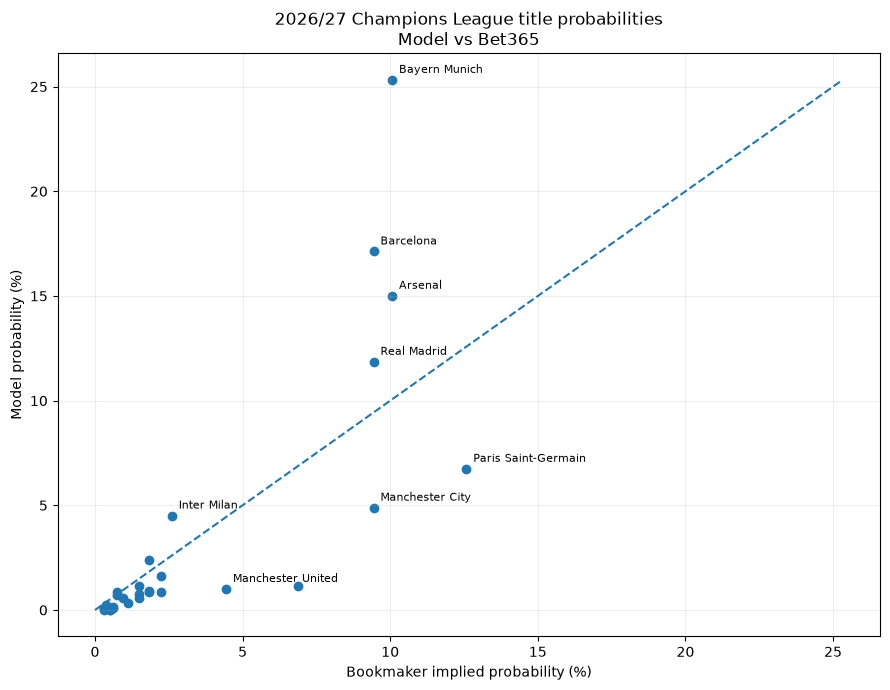

In [56]:
import matplotlib.pyplot as plt
import pandas as pd


# bet365 champions league winner odds
# stored as decimal odds

bookmaker_odds = {
    "Paris Saint-Germain": 6.0,
    "Bayern Munich": 7.5,
    "Arsenal": 7.5,
    "Barcelona": 8.0,
    "Manchester City": 8.0,
    "Real Madrid": 8.0,
    "Liverpool": 11.0,
    "Manchester United": 17.0,
    "Inter Milan": 29.0,
    "Aston Villa": 34.0,
    "Atletico Madrid": 34.0,
    "Napoli": 41.0,
    "Borussia Dortmund": 41.0,
    "Roma": 41.0,
    "RB Leipzig": 51.0,
    "Real Betis": 51.0,
    "Villarreal": 51.0,
    "Como": 67.0,
    "VfB Stuttgart": 81.0,
    "Porto": 101.0,
    "Sporting CP": 101.0,
    "Lens": 126.0,
    "PSV Eindhoven": 126.0,
    "Lille": 151.0,
    "Celtic": 151.0,
    "Feyenoord": 151.0,
    "Lyon": 151.0,
    "Galatasaray": 201.0,
    "Bodo/Glimt": 201.0,
    "Club Brugge": 201.0,
    "AEK Athens": 251.0,
    "Fenerbahce": 251.0,
    "Olympiacos": 251.0,
    "Shakhtar Donetsk": 251.0,
    "Slavia Prague": 251.0,
    "Union Saint-Gilloise": 251.0,
    "LASK": 401.0,
    "NEC Nijmegen": 401.0,
    "Sparta Prague": 401.0,
    "Viking": 401.0,
    "Levski Sofia": 501.0,
    "Omonia Nicosia": 1001.0,
    "Hearts": 2501.0
}


# build bookmaker dataframe

bookmaker_df = pd.DataFrame(
    list(bookmaker_odds.items()),
    columns=["canonical_name", "decimal_odds"]
)


# raw implied probabilities

bookmaker_df["raw_probability"] = (
    1 / bookmaker_df["decimal_odds"]
)


# remove bookmaker margin

total_probability = bookmaker_df["raw_probability"].sum()

bookmaker_df["bookmaker_probability"] = (
    bookmaker_df["raw_probability"] / total_probability
)


# merge with model results

comparison = results.merge(
    bookmaker_df,
    on="canonical_name",
    how="inner"
)


comparison["model_probability"] = (
    comparison["title_probability"] * 100
)

comparison["bookmaker_probability"] = (
    comparison["bookmaker_probability"] * 100
)


# plot

plt.figure(figsize=(9, 7))

plt.scatter(
    comparison["bookmaker_probability"],
    comparison["model_probability"]
)


# line where model = bookmaker

max_probability = max(
    comparison["bookmaker_probability"].max(),
    comparison["model_probability"].max()
)

plt.plot(
    [0, max_probability],
    [0, max_probability],
    linestyle="--"
)


# label the more important teams

for _, team in comparison.iterrows():

    if (
        team["model_probability"] >= 4
        or team["canonical_name"] == "Manchester United"
    ):

        plt.annotate(
            team["canonical_name"],
            (
                team["bookmaker_probability"],
                team["model_probability"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )


plt.xlabel("Bookmaker implied probability (%)")
plt.ylabel("Model probability (%)")

plt.title(
    "2026/27 Champions League title probabilities\n"
    "Model vs Bet365"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(
    "../figs/model_vs_bet365.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

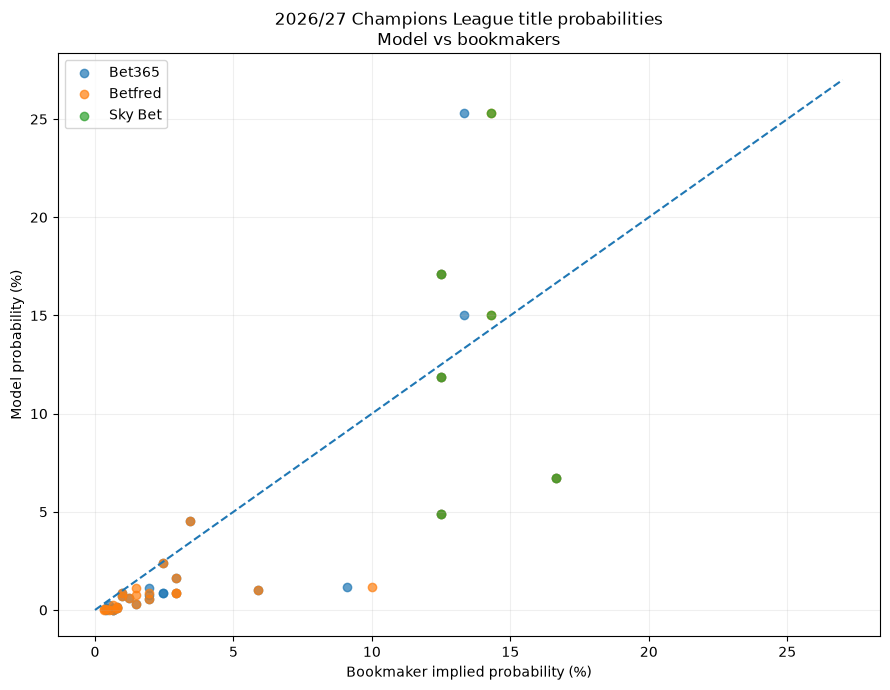

In [55]:
import matplotlib.pyplot as plt
import pandas as pd


# bookmaker odds in decimal form

bet365_odds = {
    "Paris Saint-Germain": 6.0,
    "Bayern Munich": 7.5,
    "Arsenal": 7.5,
    "Barcelona": 8.0,
    "Manchester City": 8.0,
    "Real Madrid": 8.0,
    "Liverpool": 11.0,
    "Manchester United": 17.0,
    "Inter Milan": 29.0,
    "Aston Villa": 34.0,
    "Atletico Madrid": 34.0,
    "Napoli": 41.0,
    "Borussia Dortmund": 41.0,
    "Roma": 41.0,
    "RB Leipzig": 51.0,
    "Real Betis": 51.0,
    "Villarreal": 51.0,
    "Como": 67.0,
    "VfB Stuttgart": 81.0,
    "Porto": 101.0,
    "Sporting CP": 101.0,
    "Lens": 126.0,
    "PSV Eindhoven": 126.0,
    "Lille": 151.0,
    "Celtic": 151.0,
    "Feyenoord": 151.0,
    "Lyon": 151.0,
    "Galatasaray": 201.0,
    "Bodo/Glimt": 201.0,
    "Club Brugge": 201.0,
    "AEK Athens": 251.0,
    "Fenerbahce": 251.0,
    "Shakhtar Donetsk": 251.0,
    "Slavia Prague": 251.0,
    "LASK": 401.0,
    "NEC Nijmegen": 401.0,
    "Viking": 401.0,
    "Levski Sofia": 501.0
}


betfred_odds = {
    "Paris Saint-Germain": 6.0,
    "Bayern Munich": 7.0,
    "Arsenal": 7.0,
    "Barcelona": 8.0,
    "Manchester City": 8.0,
    "Real Madrid": 8.0,
    "Liverpool": 10.0,
    "Manchester United": 17.0,
    "Inter Milan": 29.0,
    "Aston Villa": 34.0,
    "Atletico Madrid": 34.0,
    "Napoli": 34.0,
    "Borussia Dortmund": 41.0,
    "Roma": 51.0,
    "RB Leipzig": 51.0,
    "Villarreal": 67.0,
    "Real Betis": 67.0,
    "Como": 67.0,
    "VfB Stuttgart": 81.0,
    "Porto": 101.0,
    "Sporting CP": 101.0,
    "Lens": 126.0,
    "Lille": 126.0,
    "PSV Eindhoven": 126.0,
    "Lyon": 151.0,
    "Galatasaray": 151.0,
    "Celtic": 151.0,
    "Feyenoord": 201.0,
    "Club Brugge": 251.0,
    "Bodo/Glimt": 251.0,
    "Shakhtar Donetsk": 301.0,
    "Slavia Prague": 301.0,
    "AEK Athens": 301.0,
    "LASK": 501.0,
    "NEC Nijmegen": 501.0,
    "Viking": 501.0
}


# sky bet currently visible top of market

skybet_odds = {
    "Paris Saint-Germain": 6.0,
    "Bayern Munich": 7.0,
    "Arsenal": 7.0,
    "Barcelona": 8.0,
    "Manchester City": 8.0,
    "Real Madrid": 8.0
}


bookmakers = {
    "Bet365": bet365_odds,
    "Betfred": betfred_odds,
    "Sky Bet": skybet_odds
}


plt.figure(figsize=(9, 7))


for bookmaker, odds in bookmakers.items():

    bookmaker_df = pd.DataFrame(
        list(odds.items()),
        columns=["canonical_name", "decimal_odds"]
    )

    bookmaker_df["bookmaker_probability"] = (
        1 / bookmaker_df["decimal_odds"]
    ) * 100

    comparison = results.merge(
        bookmaker_df,
        on="canonical_name",
        how="inner"
    )

    comparison["model_probability"] = (
        comparison["title_probability"] * 100
    )

    plt.scatter(
        comparison["bookmaker_probability"],
        comparison["model_probability"],
        label=bookmaker,
        alpha=0.7
    )


# model = bookmaker line

plt.plot(
    [0, 27],
    [0, 27],
    linestyle="--"
)

plt.xlabel("Bookmaker implied probability (%)")
plt.ylabel("Model probability (%)")

plt.title(
    "2026/27 Champions League title probabilities\n"
    "Model vs bookmakers"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(
    "../figs/model_vs_bookmakers.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()